In [8]:
import numpy as np
import lib_debug

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


--- Strategy Selected: LCB (2D Ackley) ---
--- Starting Optimization Loop (25 iterations) ---
Iter  | Best y     | New y      | New x
--------------------------------------------------------------------------------
1     | 2.035001   | 12.644418   | [ 5.000, -5.000]
2     | 2.035001   | 13.541502   | [-5.000,  4.321]
3     | 2.035001   | 11.110519   | [-1.012, -4.723]
4     | 2.035001   | 12.638026   | [ 5.000,  5.000]
5     | 2.035001   | 6.121889   | [-1.160,  1.928]
6     | 2.035001   | 11.138696   | [-4.924, -0.778]
7     | 2.035001   | 7.652471   | [ 1.958, -1.596]
8     | 2.035001   | 11.384705   | [ 5.000, -2.909]
9     | 2.035001   | 11.640530   | [ 5.000,  0.667]
10    | 2.035001   | 11.135775   | [-2.324, -3.462]
11    | 2.035001   | 13.037478   | [-3.374,  5.000]
12    | 2.035001   | 5.889215   | [ 0.937,  1.397]
13    | 2.035001   | 11.875964   | [ 0.548,  5.000]
14    | 2.035001   | 6.445456   | [-1.594,  0.407]
15    | 2.035001   | 9.955016   | [-0.747,  3.448]
16    | 2.

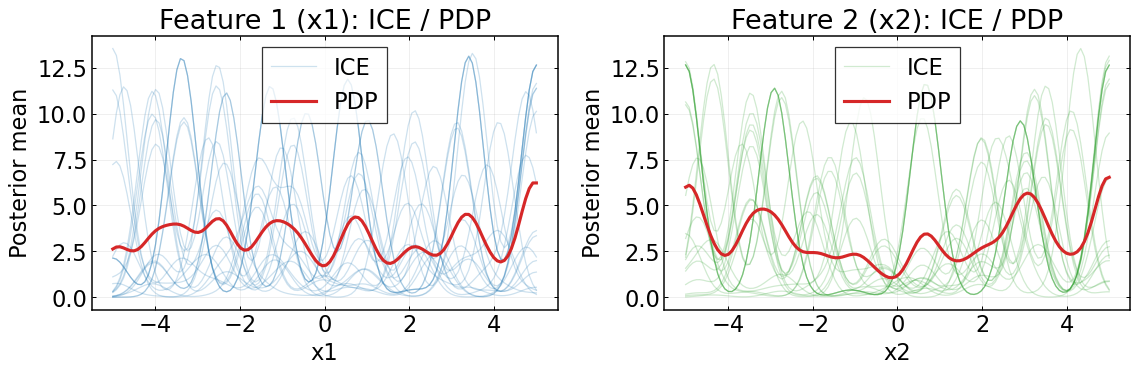

In [9]:

# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings --------------------
# Hyperparameters
gamma = 4.0
noise_std = 0.01
noise_var = noise_std ** 2

# Domain settings (2D Ackley)
dims = 2
lower_bounds = [-5.0, -5.0]
upper_bounds = [5.0, 5.0]

# Optimization Loop Settings
n_init = 20
n_iter = 25

# --- Acquisition Function (LCB only) ---
acq_func = lib_debug.lower_confidence_bound
acq_params = {"kappa": 2.0}

print("--- Strategy Selected: LCB (2D Ackley) ---")

# -------------------- 3. Initialization --------------------
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)
y_train = lib_debug.ackley_nd(X_train).reshape(-1, 1) + np.random.normal(0, noise_std, (len(X_train), 1))

# Keep copy for plotting/analysis
X_init_plot = X_train.copy()
y_init_plot = y_train.copy()

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'New x'}")
print("-" * 80)

for i in range(n_iter):
    Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

    x_new, _ = lib_debug.optimize_acquisition(
        kernel,
        acq_func,
        X_train,
        y_train,
        Ky_inv,
        gamma,
        lower_bounds,
        upper_bounds,
        acq_params,
    )

    y_new = lib_debug.ackley_nd(x_new.reshape(1, -1)) + np.random.normal(0, noise_std, (1, 1))

    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])

    current_best = np.min(y_train)
    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | [{x_new[0]: .3f}, {x_new[1]: .3f}]")

# -------------------- 5. Final fit --------------------
Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)
best_idx_final = np.argmin(y_train)
best_x = X_train[best_idx_final]
best_y = y_train[best_idx_final]

print("-" * 80)
print("Optimization Finished using LCB on 2D Ackley.")
print(f"Global Best Found: y = {best_y.item():.6f} at x = [{best_x[0]:.4f}, {best_x[1]:.4f}]")

# -------------------- 6. Correct ICE & PDP from final posterior (2D) --------------------
# Definitions used here:
# ICE_j^i(z): prediction for sample i while varying feature j to z and fixing other features.
# PDP_j(z): mean_i ICE_j^i(z)

# Grid for each feature
n_pdp_grid = 120
x1_grid = np.linspace(lower_bounds[0], upper_bounds[0], n_pdp_grid)
x2_grid = np.linspace(lower_bounds[1], upper_bounds[1], n_pdp_grid)

# Keep a manageable subset for visible ICE curves
rng = np.random.default_rng(42)
n_ice = min(20, len(X_train))
ice_idx = rng.choice(len(X_train), size=n_ice, replace=False)
X_anchor = X_train[ice_idx]

# Helper: GP posterior mean for batched points
mu_cache = {}
def gp_mu(x):
    key = tuple(np.round(x, 10))
    if key not in mu_cache:
        mu_cache[key] = lib_debug.get_posterior(kernel, np.array(x), X_train, y_train, Ky_inv, gamma)[0]
    return mu_cache[key]

# Feature-1 ICE/PDP (vary x1, fix x2 from anchors)
ice_f1 = []
for anchor in X_anchor:
    curve = []
    for z in x1_grid:
        x = [z, anchor[1]]
        curve.append(gp_mu(x))
    ice_f1.append(np.array(curve))
ice_f1 = np.array(ice_f1)
pdp_f1 = ice_f1.mean(axis=0)

# Feature-2 ICE/PDP (vary x2, fix x1 from anchors)
ice_f2 = []
for anchor in X_anchor:
    curve = []
    for z in x2_grid:
        x = [anchor[0], z]
        curve.append(gp_mu(x))
    ice_f2.append(np.array(curve))
ice_f2 = np.array(ice_f2)
pdp_f2 = ice_f2.mean(axis=0)

# -------------------- 7. Plot ICE/PDP --------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=90)

for i, curve in enumerate(ice_f1):
    axes[0].plot(x1_grid, curve, color='tab:blue', alpha=0.22, linewidth=1.0, label='ICE' if i == 0 else None)
axes[0].plot(x1_grid, pdp_f1, color='tab:red', linewidth=2.5, label='PDP')
axes[0].set_title('Feature 1 (x1): ICE / PDP')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('Posterior mean')
axes[0].grid(alpha=0.2)
axes[0].legend()

for i, curve in enumerate(ice_f2):
    axes[1].plot(x2_grid, curve, color='tab:green', alpha=0.22, linewidth=1.0, label='ICE' if i == 0 else None)
axes[1].plot(x2_grid, pdp_f2, color='tab:red', linewidth=2.5, label='PDP')
axes[1].set_title('Feature 2 (x2): ICE / PDP')
axes[1].set_xlabel('x2')
axes[1].set_ylabel('Posterior mean')
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()


In [10]:
# -------------------- sEI Bayesian Optimization PoC --------------------
# Branin, Hartmann-6, Ackley(6D) can be run with the same minimal routine.
# Default settings follow the sEI implementation request:
# n_initial = 5 * d, n_iter = 30, n_perturb_sEI = 64,
# n_mc_validation = 2048, random_seed = 0.

import lib_debug

sei_results = {}
for problem, kwargs in [
    ("branin", {"gamma": 0.02}),
    ("hartmann6", {"gamma": 1.0}),
    ("ackley", {"d": 6, "gamma": 0.05}),
]:
    result = lib_debug.run_sei_bo(
        function_name=problem,
        random_seed=0,
        n_iter=30,
        n_perturb_sEI=64,
        n_mc_validation=2048,
        **kwargs,
    )
    sei_results[problem] = result
    lib_debug.print_sei_bo_summary(result)
    print("=" * 100)


BO summary
function name: Branin
dimension d: 2
n_initial: 10
n_iter: 30
n_perturb_sEI: 64
Sigma:
[[0.5625 0.    ]
 [0.     0.5625]]
best observed y: 0.431862
best observed x: [9.38443891 2.60293468]
final recommended x: [9.4602189  2.43101542]

validation summary
candidate                 nominal_value   perturbed_mean   perturbed_std          q05          q50          q95
---------------------------------------------------------------------------------------------------------------
best_observed                  0.431862         2.956945        2.929072     0.546588     2.057615     9.314503
best_sEI_recommended           0.409399         2.706573        2.404672     0.506774     2.049654     7.275589

robust best by perturbed_mean: best_sEI_recommended
BO summary
function name: Hartmann-6
dimension d: 6
n_initial: 30
n_iter: 30
n_perturb_sEI: 64
Sigma:
[[0.0009 0.     0.     0.     0.     0.    ]
 [0.     0.0009 0.     0.     0.     0.    ]
 [0.     0.     0.0009 0.     0.     0.   